
# Caso de Estudio: Predicción de Exportaciones de Café Colombiano ☕🇨🇴

En este notebook vamos a aplicar lo aprendido para **modelar una serie de tiempo real**: exportaciones mensuales de café de Colombia.

El foco no es “ganar un benchmark”, sino entrenar una **RNN (SimpleRNN)** y analizar si:

- captura la **estacionalidad** (picos por cosecha),
- sigue **tendencias** de mediano plazo,
- y dónde se queda corta (puente perfecto para **LSTM/GRU**).

> Importante: el archivo que usaremos es `Exportaciones.xlsx`. Abajo te explico **dónde ubicarlo** para que Jupyter Book lo lea sin problemas.



## 1. Contexto de negocio

La producción y exportación de café no es lineal: depende de clima, cosechas, logística y demanda global.

**Objetivo:** entrenar un modelo recurrente que aprenda del pasado (en este dataset: **2004-01 a 2014-12**) para pronosticar exportaciones futuras (miles de sacos de 60kg).

> Nota: si luego consigues datos más recientes, el pipeline funciona igual.



## 2. Carga y exploración de datos

### 📁 ¿Dónde dejar el archivo en un Jupyter Book?

Recomendación de estructura (desde la raíz del repositorio del book):

```
my-book/
  _config.yml
  _toc.yml
  content/
    rnn/
      03_caso_cafe.ipynb   <-- este notebook
  data/
    Exportaciones.xlsx     <-- deja el archivo aquí
```

Así, el notebook puede leerlo con una ruta relativa estable: `data/Exportaciones.xlsx`.

> Si estás ejecutando localmente el book, **la carpeta `data/` debe estar presente** para que el notebook encuentre el archivo.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# -----------------------------
# Robust path resolution
# -----------------------------
# We try a few common locations so the notebook works both:
# - when run from the repo root
# - when built by Jupyter Book
# - when run from inside the content/rnn folder

CANDIDATE_PATHS = [
    Path("data/Exportaciones.xlsx"),
    Path("../data/Exportaciones.xlsx"),
    Path("../../data/Exportaciones.xlsx"),
    Path("Exportaciones.xlsx"),
]

DATA_PATH = None
for p in CANDIDATE_PATHS:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find 'Exportaciones.xlsx'. "
        "Place it in 'data/Exportaciones.xlsx' (recommended) or alongside this notebook."
    )

print(f"✅ Using data file: {DATA_PATH.resolve()}")

# Load dataset
df = pd.read_excel(DATA_PATH)

# Basic validation
required_cols = {"Fechas", "Exportaciones"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing expected columns: {missing}. Found columns: {list(df.columns)}")

df["Fechas"] = pd.to_datetime(df["Fechas"])
df = df.set_index("Fechas").sort_index()

print(f"Total months: {len(df)}")
display(df.head())


✅ Using data file: D:\Documentos\RNN Manual\data\Exportaciones.xlsx


Total months: 132


,Exportaciones
Fechas,
2004-01-01,897.0
2004-02-01,973.0
2004-03-01,885.0
2004-04-01,806.0
2004-05-01,789.0


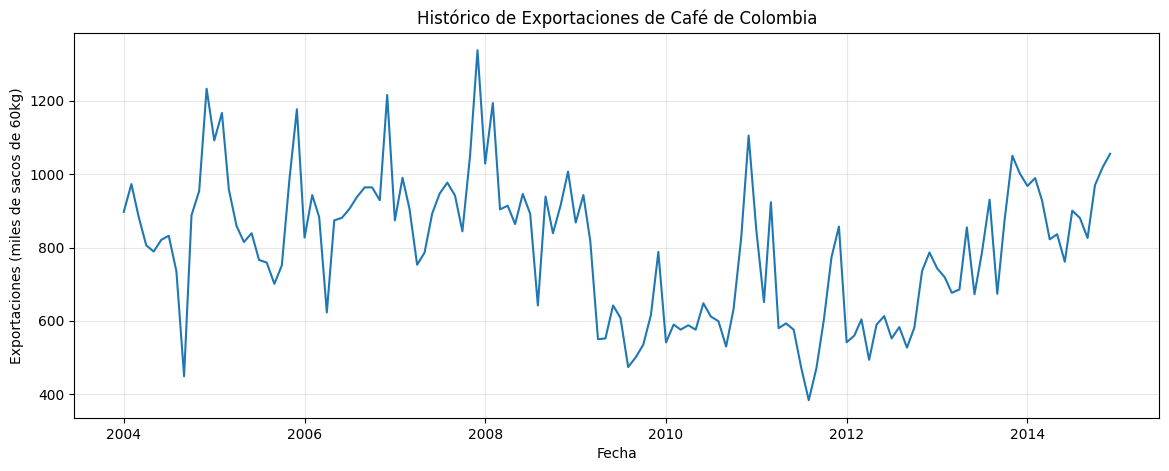

Rango de fechas: 2004-01-01 → 2014-12-01
Exportaciones - min/mean/max: 383.6 800.8711363636363 1338.0


In [2]:

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Exportaciones"])
plt.title("Histórico de Exportaciones de Café de Colombia")
plt.xlabel("Fecha")
plt.ylabel("Exportaciones (miles de sacos de 60kg)")
plt.grid(True, alpha=0.3)
plt.show()

print("Rango de fechas:", df.index.min().date(), "→", df.index.max().date())
print("Exportaciones - min/mean/max:", float(df["Exportaciones"].min()), float(df["Exportaciones"].mean()), float(df["Exportaciones"].max()))



### Lectura visual (qué buscar)

- **Estacionalidad:** picos que se repiten en meses similares cada año.
- **Tendencias:** periodos donde sube o baja por varios meses.
- **Volatilidad:** cambios bruscos que una RNN simple puede “suavizar” demasiado.



## 3. Preprocesamiento: Normalización

Las RNN entrenan mejor cuando la escala es estable (por ejemplo, entre 0 y 1).
Usaremos `MinMaxScaler`.

> Buen hábito: ajustamos el scaler *solo con train* para evitar fuga de información.


In [3]:

from sklearn.preprocessing import MinMaxScaler

values = df[["Exportaciones"]].values.astype(float)



## 4. Ingeniería de Características: Ventana Deslizante

Convertimos la serie en un problema supervisado:

- **X:** últimos `LOOK_BACK` meses
- **y:** mes siguiente

Usaremos `LOOK_BACK = 12` (un año de historia para predecir el próximo mes).


In [4]:

def create_supervised_windows(series_2d: np.ndarray, look_back: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Build supervised learning windows from a univariate time series.

    Args:
        series_2d: Array of shape (T, 1)
        look_back: Number of past time steps to use

    Returns:
        X: Array of shape (N, look_back, 1)
        y: Array of shape (N, 1)
    """
    if series_2d.ndim != 2 or series_2d.shape[1] != 1:
        raise ValueError(f"Expected shape (T, 1), got {series_2d.shape}")

    X_list, y_list = [], []
    for i in range(len(series_2d) - look_back):
        X_list.append(series_2d[i : i + look_back, 0])
        y_list.append(series_2d[i + look_back, 0])

    X = np.array(X_list, dtype=float).reshape(-1, look_back, 1)
    y = np.array(y_list, dtype=float).reshape(-1, 1)
    return X, y

LOOK_BACK = 12



## 5. Partición de Datos: Respetando el Tiempo ⏳

En series de tiempo **no** barajamos aleatoriamente.

- Train: primeros 80%
- Test: últimos 20% (el “futuro”)

Además, **ajustamos el scaler solo con train** para evitar leakage.


In [5]:

# Time-based split index (on the original series)
split_idx = int(len(values) * 0.80)

train_vals = values[:split_idx]
test_vals = values[split_idx:]

# Fit scaler only on train
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_vals)
test_scaled = scaler.transform(test_vals)

# Build supervised windows
X_train, y_train = create_supervised_windows(train_scaled, LOOK_BACK)
X_test, y_test = create_supervised_windows(test_scaled, LOOK_BACK)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

# Dates aligned to each target y within each split
train_dates = df.index[:split_idx][LOOK_BACK:]
test_dates = df.index[split_idx:][LOOK_BACK:]


X_train: (93, 12, 1) y_train: (93, 1)
X_test : (15, 12, 1) y_test : (15, 1)



## 6. Modelo: SimpleRNN en Keras

Aquí usamos una `SimpleRNN` de Keras.

- `units=50`: tamaño de la memoria interna
- activación `tanh`
- salida densa (1 valor)

> Si tu ambiente no tiene TensorFlow: `pip install tensorflow`


In [6]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

tf.random.set_seed(42)

model = Sequential([
    SimpleRNN(units=50, activation="tanh", input_shape=(LOOK_BACK, 1)),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()


Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 simple_rnn (SimpleRNN)      (None, 50)                2600      


 dense (Dense)               (None, 1)                 51        


Total params: 2651 (10.36 KB)


Trainable params: 2651 (10.36 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


Epoch 1/50


1/3 [=========>....................] - ETA: 2s - loss: 0.7633

3/3 [==============================] - 1s 119ms/step - loss: 0.5507 - val_loss: 0.2955


Epoch 2/50


1/3 [=========>....................] - ETA: 0s - loss: 0.1630

...

1/3 [=========>....................] - ETA: 0s - loss: 0.0198

3/3 [==============================] - 0s 13ms/step - loss: 0.0171 - val_loss: 0.0142


Epoch 50/50


1/3 [=========>....................] - ETA: 0s - loss: 0.0206

3/3 [==============================] - 0s 16ms/step - loss: 0.0171 - val_loss: 0.0143


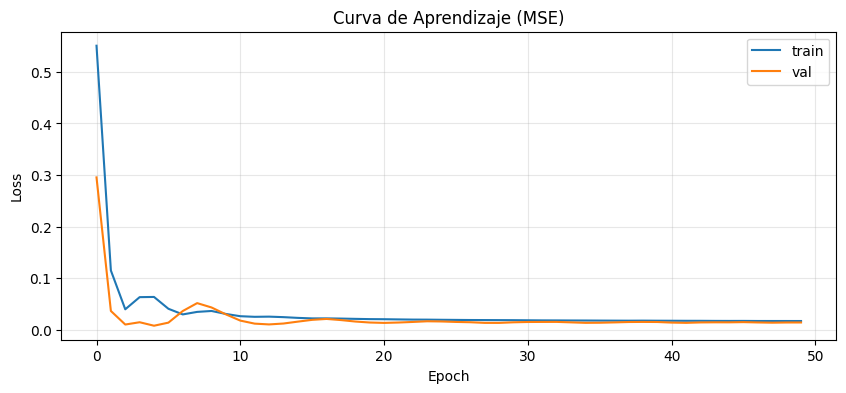

In [7]:

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Curva de Aprendizaje (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



## 7. Predicción y Evaluación

Vamos a:

1) Predecir en train y test  
2) Volver a escala real (inverse transform)  
3) Evaluar con **RMSE** y **MAE**  
4) Graficar Real vs Predicho en el tiempo


In [8]:

from sklearn.metrics import mean_absolute_error, mean_squared_error

train_pred = model.predict(X_train, verbose=0)
test_pred = model.predict(X_test, verbose=0)

# Inverse transform (back to real scale)
y_train_real = scaler.inverse_transform(y_train)
y_test_real = scaler.inverse_transform(y_test)
train_pred_real = scaler.inverse_transform(train_pred)
test_pred_real = scaler.inverse_transform(test_pred)

def rmse(y_true: np.ndarray, y_hat: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_hat)))

train_rmse = rmse(y_train_real, train_pred_real)
test_rmse = rmse(y_test_real, test_pred_real)

train_mae = float(mean_absolute_error(y_train_real, train_pred_real))
test_mae = float(mean_absolute_error(y_test_real, test_pred_real))

print(f"Train RMSE: {train_rmse:.2f} | Train MAE: {train_mae:.2f}")
print(f" Test RMSE: {test_rmse:.2f} |  Test MAE: {test_mae:.2f}")


Train RMSE: 124.30 | Train MAE: 95.81
 Test RMSE: 113.94 |  Test MAE: 91.29


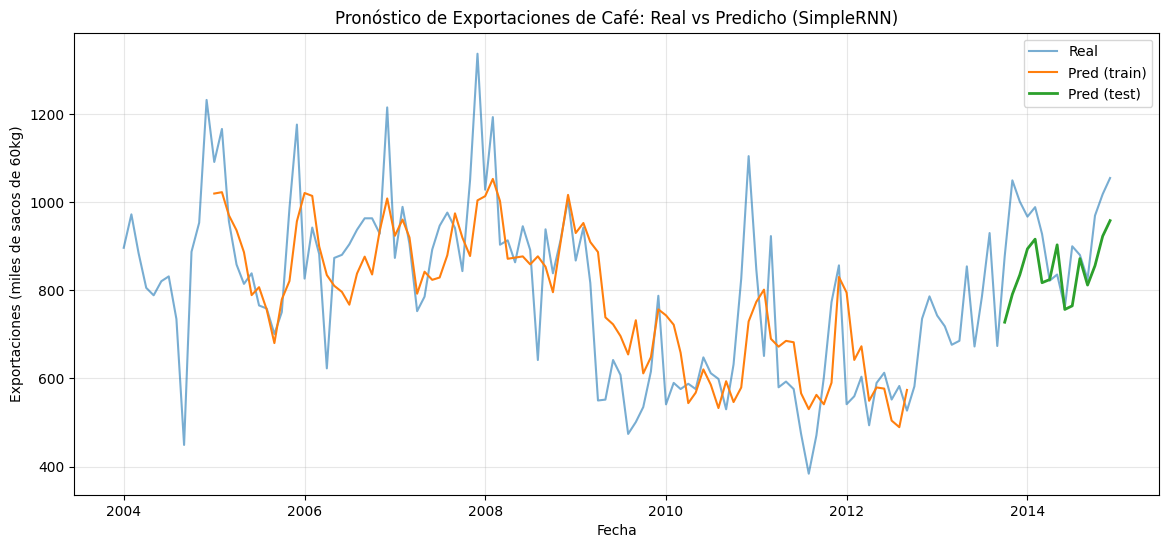

In [9]:

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Exportaciones"].values, label="Real", alpha=0.6)

full_real = df["Exportaciones"].values.reshape(-1, 1)

train_plot = np.full_like(full_real, fill_value=np.nan, dtype=float)
test_plot = np.full_like(full_real, fill_value=np.nan, dtype=float)

# Train predictions align with df.index[LOOK_BACK:split_idx]
train_plot[LOOK_BACK:split_idx, 0] = train_pred_real[:, 0]

# Test predictions align with df.index[split_idx + LOOK_BACK : ...]
test_start = split_idx + LOOK_BACK
test_end = test_start + len(test_pred_real)
test_plot[test_start:test_end, 0] = test_pred_real[:, 0]

plt.plot(df.index, train_plot[:, 0], label="Pred (train)")
plt.plot(df.index, test_plot[:, 0], label="Pred (test)", linewidth=2)

plt.title("Pronóstico de Exportaciones de Café: Real vs Predicho (SimpleRNN)")
plt.xlabel("Fecha")
plt.ylabel("Exportaciones (miles de sacos de 60kg)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



### Interpretación (qué mirar)

- La línea de **test** debería seguir (aunque sea aproximadamente):  
  - subidas y bajadas generales (tendencia), y ojalá  
  - picos estacionales

Si la predicción queda “rezagada” o tiende a repetir valores recientes, es común en **SimpleRNN**.

Esto prepara el terreno para LSTM/GRU, que manejan mejor dependencias más largas.



## 8. Reto Final: Mejora con LSTM

Cambia la capa `SimpleRNN(...)` por `LSTM(...)` y compara:

- curva de pérdida
- métricas (RMSE/MAE)
- ajuste visual en test

Pista mínima:

```python
from tensorflow.keras.layers import LSTM

model = Sequential([
    LSTM(units=50, input_shape=(LOOK_BACK, 1)),
    Dense(1)
])
```
